In [1]:
# Temporary execution bootstrap for this kernel.
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "pandas",
    "numpy",
    "matplotlib",
    "pyarrow",
    "requests",
    "pyyaml",
    "aiohttp",
])
print("Notebook runtime dependencies installed.")

Notebook runtime dependencies installed.


In [2]:
# ── Scanner config ─────────────────────────────────────────────────────────
N_SYMBOLS        = 50         # top N Binance USDT pairs by 24h volume
INTERVALS        = ["15m", "1h", "4h"]
FORCE_FULL_FETCH = False      # True = re-download all candles from scratch

# ── Filter params (must match 08_trend_id.ipynb for consistency) ────────────
USE_PARENT_RELATIVE_FILTER = True
MIN_IMPULSE_PARENT_RATIO   = 0.15
USE_MOMENTUM_FILTER        = True
MIN_MOMENTUM_RATIO         = 0.5
USE_DOMINANCE_FILTER       = True
MIN_DOMINANCE_RATIO        = 1.5

FILTER_CONFIG = {
    "use_parent_relative_filter": USE_PARENT_RELATIVE_FILTER,
    "min_impulse_parent_ratio":   MIN_IMPULSE_PARENT_RATIO,
    "use_momentum_filter":        USE_MOMENTUM_FILTER,
    "min_momentum_ratio":         MIN_MOMENTUM_RATIO,
    "use_dominance_filter":       USE_DOMINANCE_FILTER,
    "min_dominance_ratio":        MIN_DOMINANCE_RATIO,
}

In [3]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.scanner.market_scanner import fetch_top_symbols, run_scanner

symbols = fetch_top_symbols(N_SYMBOLS)
results_df = run_scanner(symbols, INTERVALS, FILTER_CONFIG, force_full=FORCE_FULL_FETCH)
print(f"\nResults shape: {results_df.shape}")
print(f"Columns: {list(results_df.columns)}")
print(f"\nFirst 5 rows:")
print(results_df.head())
print(f"\nFailed rows:")
print(results_df[results_df['error'].notna()][['symbol','interval','error']])

total = len(results_df)
successful = results_df['error'].isna().sum()
failed = results_df['error'].notna().sum()
print(f"\nData quality:")
print(f"  Total rows: {total} (expected {N_SYMBOLS * len(INTERVALS)})")
print(f"  Successful: {successful} ({100*successful/total:.1f}%)")
print(f"  Failed: {failed} ({100*failed/total:.1f}%)")
print(f"  Trend distribution:\n{results_df['trend'].value_counts(dropna=False)}")
print(f"  Phase distribution:\n{results_df['current_phase'].value_counts(dropna=False)}")
print(f"  Velocity trend distribution:\n{results_df['velocity_trend'].value_counts(dropna=False)}")

Universe: top 50 USDT pairs by 24h volume fetched. ['BTCUSDT', 'ETHUSDT', 'NIGHTUSDT', 'PAXGUSDT', 'SOLUSDT', 'USD1USDT', 'XRPUSDT', 'BNBUSDT', 'TAOUSDT', 'TRXUSDT', 'DOGEUSDT', 'BANANAS31USDT', 'ZECUSDT', 'ADAUSDT', 'LINKUSDT', 'PEPEUSDT', 'SUIUSDT', 'UUSDT', 'RLUSDUSDT', 'ASTERUSDT', 'EURUSDT', 'KATUSDT', 'LTCUSDT', 'AVAXUSDT', 'WLFIUSDT', 'GUNUSDT', 'NEARUSDT', 'FETUSDT', 'SIGNUSDT', 'WLDUSDT', 'FILUSDT', 'TURBOUSDT', 'DASHUSDT', 'ENAUSDT', 'USDEUSDT', 'KITEUSDT', 'BCHUSDT', 'GIGGLEUSDT', 'TRUMPUSDT', 'ROBOUSDT', 'APTUSDT', 'PUMPUSDT', 'SKYUSDT', 'SAHARAUSDT', 'HBARUSDT', 'XUSDUSDT', 'OPNUSDT', 'XLMUSDT', 'STOUSDT', 'DEXEUSDT']
Starting scan: 0 binance + 0 deriv symbols × 3 timeframes = 0 combinations.
Scan complete.
Total combinations: 0
Successful: 0
Failed: 0
Total time: 0m 0s
Trending (up+down): 0 / 0 (0.0%)
Ranging: 0 / 0 (0.0%)

Results shape: (0, 20)
Columns: ['symbol', 'interval', 'trend', 'current_phase', 'confirmed_leg_count', 'impulse_count', 'retracement_count', 'mean_im

C:\Users\Ausleihe\AppData\Local\Temp\ipykernel_18792\3142217435.py:24: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  Successful: {successful} ({100*successful/total:.1f}%)")
C:\Users\Ausleihe\AppData\Local\Temp\ipykernel_18792\3142217435.py:25: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  Failed: {failed} ({100*failed/total:.1f}%)")


C:\Users\Ausleihe\AppData\Local\Temp\ipykernel_18792\3468342337.py:39: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(heat, cmap=cmap, norm=norm, aspect='auto')


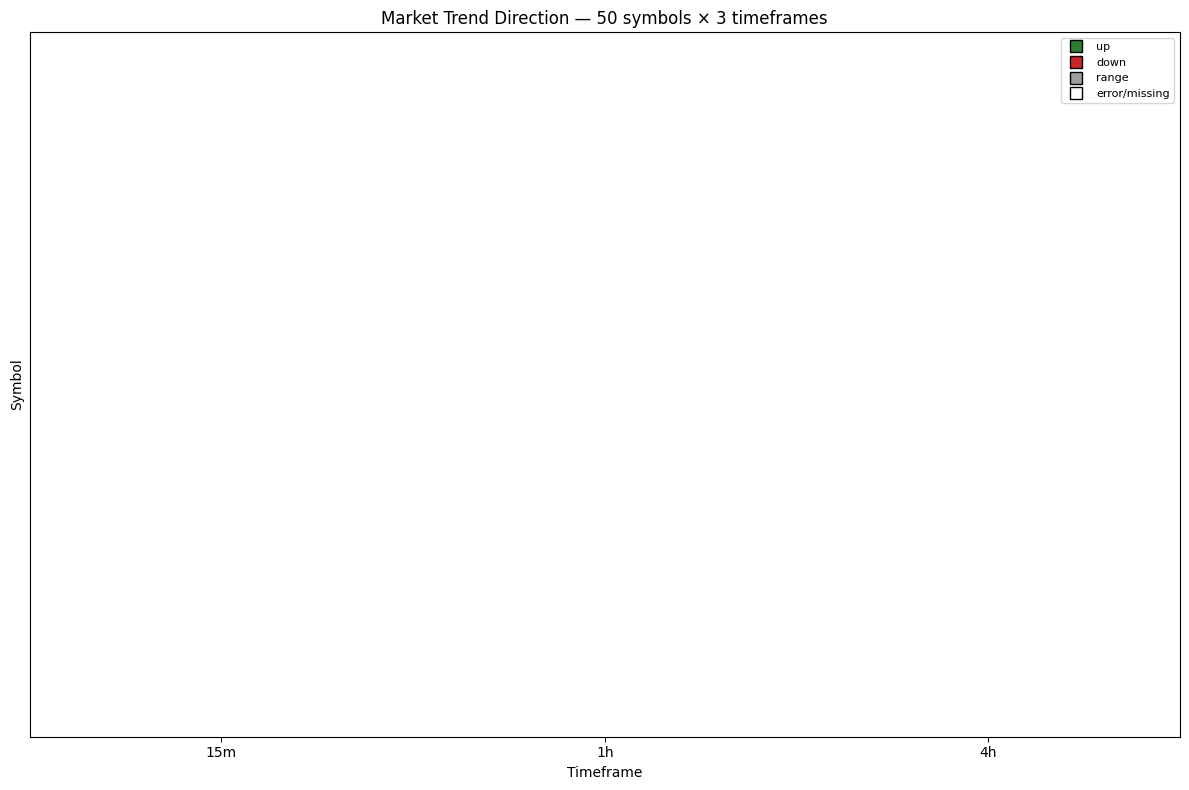

Heatmap verification:
- Symbols plotted: 0 (expected 0)
- Timeframes plotted: 3 (expected 3)
- Up: 0 | Down: 0 | Range: 0 | Error: 0
- Multi-TF aligned down (all intervals = down): 0 symbols
- Multi-TF aligned up (all intervals = up): 0 symbols
- Mixed direction (not all same): 0 symbols


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

successful_df = results_df[results_df['error'].isna()].copy()
symbol_order = sorted(results_df['symbol'].dropna().unique().tolist())
interval_order = INTERVALS

trend_to_code = {'up': 0, 'down': 1, 'range': 2}
phase_to_label = {'impulse': 'I', 'retracement': 'R', 'unknown': '?'}

heat = np.full((len(symbol_order), len(interval_order)), 3, dtype=int)
phase_labels = np.full((len(symbol_order), len(interval_order)), '?', dtype=object)

sym_idx = {s: i for i, s in enumerate(symbol_order)}
int_idx = {itv: j for j, itv in enumerate(interval_order)}

for _, row in results_df.iterrows():
    s = row['symbol']
    itv = row['interval']
    if pd.isna(s) or pd.isna(itv) or s not in sym_idx or itv not in int_idx:
        continue
    i = sym_idx[s]
    j = int_idx[itv]
    if pd.notna(row['error']):
        heat[i, j] = 3
        phase_labels[i, j] = '?'
    else:
        t = row['trend'] if pd.notna(row['trend']) else 'range'
        p = row['current_phase'] if pd.notna(row['current_phase']) else 'unknown'
        heat[i, j] = trend_to_code.get(t, 3)
        phase_labels[i, j] = phase_to_label.get(p, '?')

cmap = ListedColormap(['#2e7d32', '#c62828', '#9e9e9e', '#ffffff'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(12, max(8, len(symbol_order) * 0.22)))
im = ax.imshow(heat, cmap=cmap, norm=norm, aspect='auto')

for i in range(len(symbol_order)):
    for j in range(len(interval_order)):
        ax.text(j, i, phase_labels[i, j], ha='center', va='center', fontsize=7, color='black')

ax.set_xticks(range(len(interval_order)))
ax.set_xticklabels(interval_order)
ax.set_yticks(range(len(symbol_order)))
ax.set_yticklabels(symbol_order, fontsize=7)
ax.set_title(f"Market Trend Direction — {N_SYMBOLS} symbols × {len(INTERVALS)} timeframes")
ax.set_xlabel('Timeframe')
ax.set_ylabel('Symbol')

legend_labels = [('up', '#2e7d32'), ('down', '#c62828'), ('range', '#9e9e9e'), ('error/missing', '#ffffff')]
handles = [plt.Line2D([0], [0], marker='s', color='w', markerfacecolor=c, markeredgecolor='black', markersize=8, linestyle='') for _, c in legend_labels]
ax.legend(handles, [lbl for lbl, _ in legend_labels], loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

up_count = int((heat == 0).sum())
down_count = int((heat == 1).sum())
range_count = int((heat == 2).sum())
error_count = int((heat == 3).sum())

aligned_down = 0
aligned_up = 0
mixed = 0
for s in symbol_order:
    sub = successful_df[successful_df['symbol'] == s]
    if len(sub) != len(interval_order):
        mixed += 1
        continue
    trends = sub['trend'].tolist()
    if all(t == 'down' for t in trends):
        aligned_down += 1
    elif all(t == 'up' for t in trends):
        aligned_up += 1
    elif len(set(trends)) == 1:
        pass
    else:
        mixed += 1

print('Heatmap verification:')
print(f'- Symbols plotted: {len(symbol_order)} (expected {len(symbol_order)})')
print(f'- Timeframes plotted: {len(interval_order)} (expected {len(interval_order)})')
print(f'- Up: {up_count} | Down: {down_count} | Range: {range_count} | Error: {error_count}')
print(f'- Multi-TF aligned down (all intervals = down): {aligned_down} symbols')
print(f'- Multi-TF aligned up (all intervals = up): {aligned_up} symbols')
print(f'- Mixed direction (not all same): {mixed} symbols')

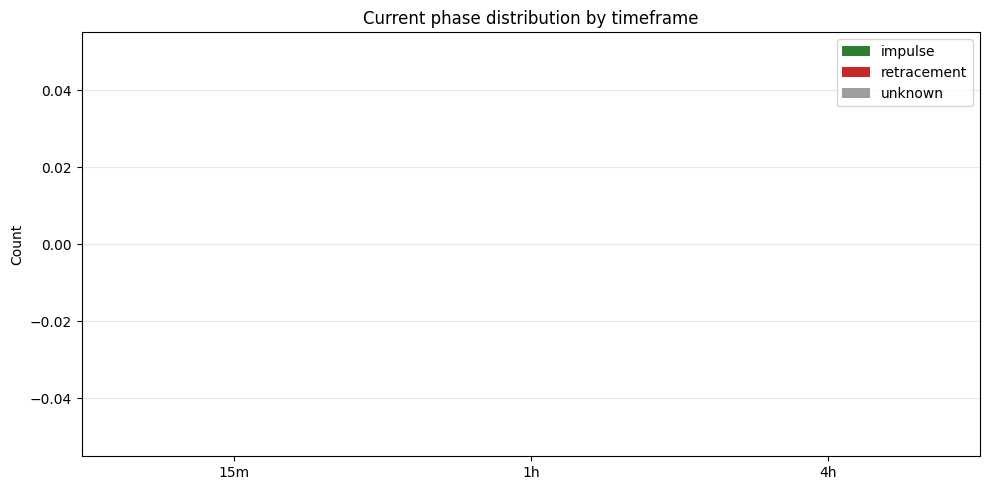

Phase verification per timeframe:
15m → impulse: 0 | retracement: 0 | unknown: 0
1h  → impulse: 0 | retracement: 0 | unknown: 0
4h  → impulse: 0 | retracement: 0 | unknown: 0


In [5]:
phase_df = results_df[results_df['error'].isna()].copy()
phase_df['current_phase'] = phase_df['current_phase'].fillna('unknown')

phase_order = ['impulse', 'retracement', 'unknown']
counts = phase_df.groupby(['interval', 'current_phase']).size().unstack(fill_value=0)
for phase in phase_order:
    if phase not in counts.columns:
        counts[phase] = 0
counts = counts[phase_order].reindex(INTERVALS).fillna(0)

x = np.arange(len(INTERVALS))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, counts['impulse'].values, width=w, label='impulse', color='#2e7d32')
ax.bar(x, counts['retracement'].values, width=w, label='retracement', color='#c62828')
ax.bar(x + w, counts['unknown'].values, width=w, label='unknown', color='#9e9e9e')
ax.set_xticks(x)
ax.set_xticklabels(INTERVALS)
ax.set_ylabel('Count')
ax.set_title('Current phase distribution by timeframe')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Phase verification per timeframe:')
for interval in INTERVALS:
    row = counts.loc[interval] if interval in counts.index else pd.Series({p: 0 for p in phase_order})
    print(f"{interval:<3} → impulse: {int(row['impulse'])} | retracement: {int(row['retracement'])} | unknown: {int(row['unknown'])}")
    interval_total = int(row.sum())
    if interval_total > 0:
        dominant_phase = row.idxmax()
        dominant_pct = (row.max() / interval_total) * 100.0
        if dominant_pct > 70.0:
            print(f"WARNING: {interval} has {dominant_pct:.1f}% of markets in {dominant_phase} — possible regime uniformity.")

TypeError: Column 'mean_impulse_move_pct' has dtype object, cannot use method 'nlargest' with this dtype

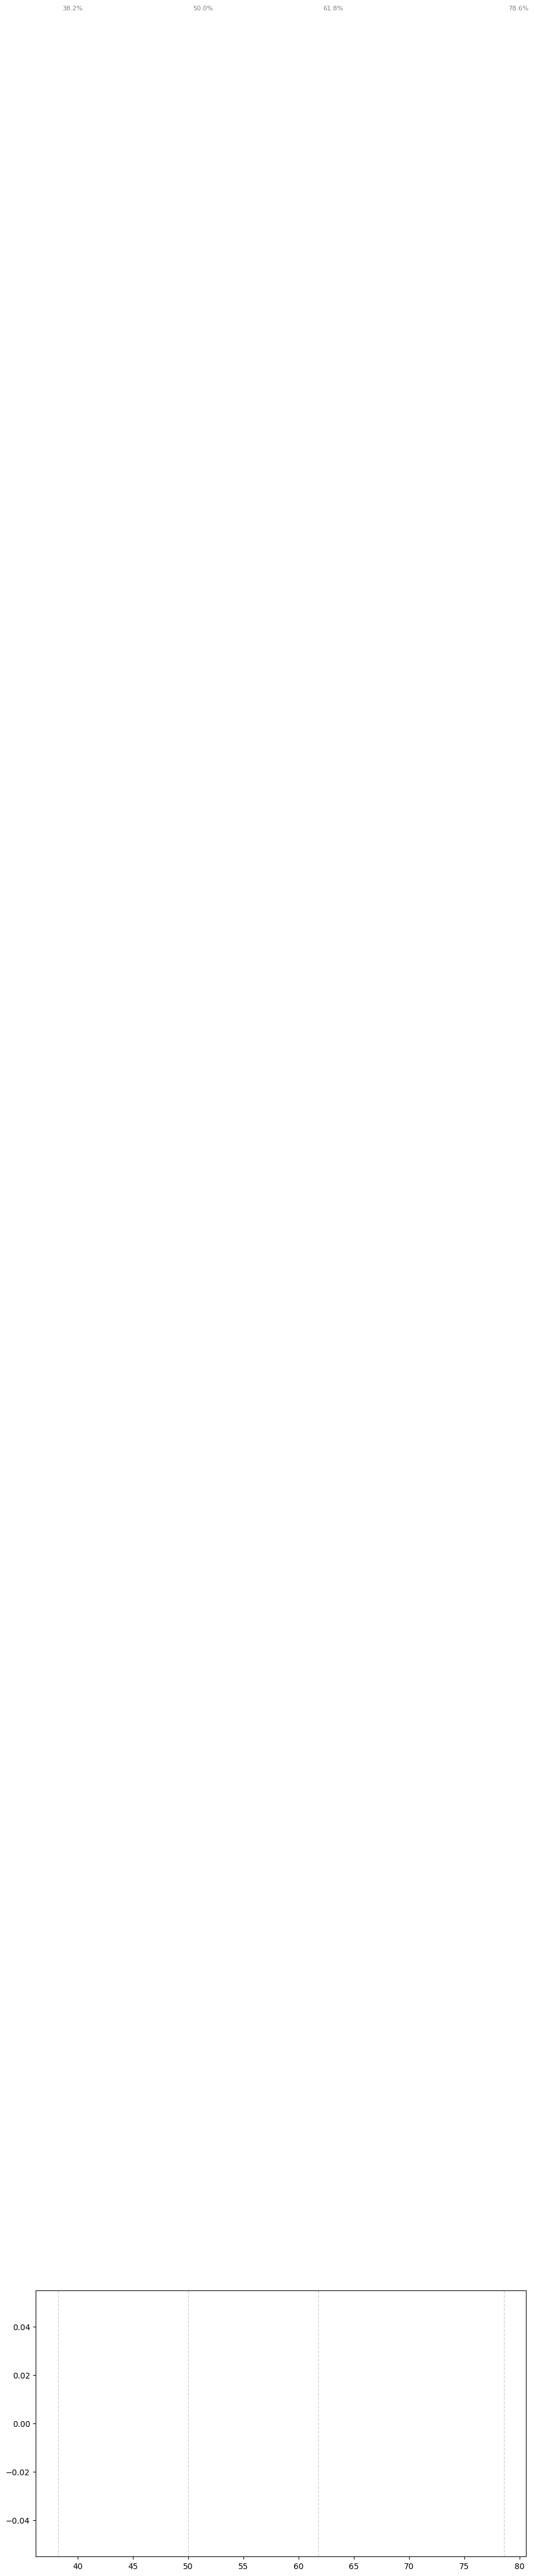

In [6]:
scatter_df = results_df[results_df['error'].isna()].copy()
scatter_df = scatter_df.dropna(subset=['mean_retracement_depth_pct', 'mean_impulse_move_pct', 'confirmed_leg_count', 'trend'])
scatter_df = scatter_df[scatter_df['anomalous'] != True]

trend_colors = {'up': '#2e7d32', 'down': '#c62828', 'range': '#9e9e9e'}
colors = scatter_df['trend'].map(trend_colors).fillna('#9e9e9e')
sizes = scatter_df['confirmed_leg_count'].fillna(0).astype(float) * 20.0

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(
    scatter_df['mean_retracement_depth_pct'].astype(float),
    scatter_df['mean_impulse_move_pct'].astype(float),
    c=colors,
    s=sizes,
    alpha=0.75,
    edgecolors='black',
    linewidths=0.3,
)

for x_ref in [38.2, 50.0, 61.8, 78.6]:
    ax.axvline(x_ref, color='lightgrey', linewidth=1, linestyle='--', zorder=0)
    ax.text(x_ref + 0.4, ax.get_ylim()[1] * 0.98 if len(scatter_df) else 1, f'{x_ref}%', color='grey', fontsize=8, va='top')

label_rows = pd.concat([
    scatter_df.nlargest(5, 'mean_impulse_move_pct'),
    scatter_df.nsmallest(5, 'mean_retracement_depth_pct')
]).drop_duplicates(subset=['symbol', 'interval'])

for _, row in label_rows.iterrows():
    ax.text(
        float(row['mean_retracement_depth_pct']) + 0.4,
        float(row['mean_impulse_move_pct']) + 0.2,
        f"{row['symbol']}",
        fontsize=7,
    )

ax.set_xlabel('Mean retracement depth %')
ax.set_ylabel('Mean impulse move %')
ax.set_title('Impulse strength vs retracement depth')
ax.grid(True, alpha=0.3)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=trend_colors['down'], label='down', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=trend_colors['up'], label='up', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=trend_colors['range'], label='range', markersize=8),
]
ax.legend(handles=legend_handles, title='Trend')
plt.tight_layout()
plt.show()

if len(scatter_df) > 0:
    deepest = scatter_df.loc[scatter_df['mean_retracement_depth_pct'].astype(float).idxmax()]
    strongest = scatter_df.loc[scatter_df['mean_impulse_move_pct'].astype(float).idxmax()]
    shallowest = scatter_df.loc[scatter_df['mean_retracement_depth_pct'].astype(float).idxmin()]
    print('Scatter verification:')
    print(f"- Points plotted: {len(scatter_df)}")
    print(f"- Mean impulse move across universe: {scatter_df['mean_impulse_move_pct'].astype(float).mean():.2f}%")
    print(f"- Mean retracement depth across universe: {scatter_df['mean_retracement_depth_pct'].astype(float).mean():.2f}%")
    print(f"- Deepest retracement: {deepest['symbol']} {deepest['interval']} at {float(deepest['mean_retracement_depth_pct']):.2f}%")
    print(f"- Strongest impulse: {strongest['symbol']} {strongest['interval']} at {float(strongest['mean_impulse_move_pct']):.2f}%")
    print(f"- Shallowest retracement (strongest momentum): {shallowest['symbol']} {shallowest['interval']} at {float(shallowest['mean_retracement_depth_pct']):.2f}%")
else:
    print('Scatter verification:')
    print('- Points plotted: 0')
    print('- No valid non-NaN rows available for scatter metrics.')
print('Anomalous rows excluded from scatter:', int((results_df['anomalous'] == True).sum()))


In [ ]:
rank_df = results_df[results_df['error'].isna()].copy()
rank_df['score'] = 0
rank_df.loc[rank_df['trend'].isin(['up', 'down']), 'score'] += 30
rank_df.loc[rank_df['current_phase'] == 'retracement', 'score'] += 20
rank_df.loc[rank_df['velocity_trend'] == 'accelerating', 'score'] += 20
rank_df.loc[rank_df['choch_intact'] == True, 'score'] += 15
rank_df.loc[
    rank_df['mean_retracement_depth_pct'].notna()
    & (rank_df['mean_retracement_depth_pct'].astype(float) >= 38.2)
    & (rank_df['mean_retracement_depth_pct'].astype(float) <= 78.6),
    'score',
] += 10
rank_df.loc[rank_df['any_choch_risk'] == False, 'score'] += 5

rank_df = rank_df.sort_values(['score', 'mean_impulse_move_pct'], ascending=[False, False]).reset_index(drop=True)
rank_df['rank'] = rank_df.index + 1

cols = [
    'rank', 'symbol', 'interval', 'trend', 'current_phase', 'score',
    'mean_impulse_move_pct', 'mean_retracement_depth_pct', 'velocity_trend', 'choch_intact'
]
top20 = rank_df.head(20)[cols].copy()
bottom5 = rank_df.tail(5)[cols].copy()

print('Top 20 ranked markets by trend score:')
print('Rank | Symbol    | TF  | Trend | Phase       | Score | Impulse% | Ret depth% | Velocity     | CHoCH intact')
print('---- | --------- | --- | ----- | ----------- | ----- | -------- | ---------- | ------------ | ------------')
for _, row in top20.iterrows():
    impulse = 'nan' if pd.isna(row['mean_impulse_move_pct']) else f"{float(row['mean_impulse_move_pct']):.2f}"
    depth = 'nan' if pd.isna(row['mean_retracement_depth_pct']) else f"{float(row['mean_retracement_depth_pct']):.2f}"
    print(
        f"{int(row['rank']):<4} | {str(row['symbol']):<9} | {str(row['interval']):<3} | {str(row['trend']):<5} | "
        f"{str(row['current_phase']):<11} | {int(row['score']):<5} | {impulse:<8} | {depth:<10} | "
        f"{str(row['velocity_trend']):<12} | {str(row['choch_intact'])}"
    )

print('\nBottom 5 scored markets (sanity check):')
print(bottom5.to_string(index=False))

Top 20 ranked markets by trend score:
Rank | Symbol    | TF  | Trend | Phase       | Score | Impulse% | Ret depth% | Velocity     | CHoCH intact
---- | --------- | --- | ----- | ----------- | ----- | -------- | ---------- | ------------ | ------------
1    | WLDUSDT   | 1h  | down  | retracement | 100   | 43.83    | 67.80      | accelerating | True
2    | DOTUSDT   | 1h  | down  | retracement | 100   | 41.97    | 72.80      | accelerating | True
3    | ADAUSDT   | 1h  | down  | retracement | 100   | 40.78    | 56.30      | accelerating | True
4    | ZECUSDT   | 15m | up    | retracement | 100   | 31.41    | 50.50      | accelerating | True
5    | EURUSDT   | 15m | down  | retracement | 100   | 2.52     | 47.90      | accelerating | True
6    | BTCUSDT   | 4h  | down  | retracement | 90    | 37.43    | 35.20      | accelerating | True
7    | TRXUSDT   | 15m | up    | retracement | 90    | 4.44     | 33.10      | accelerating | True
8    | VANRYUSDT | 4h  | down  | retracement | 80    | 

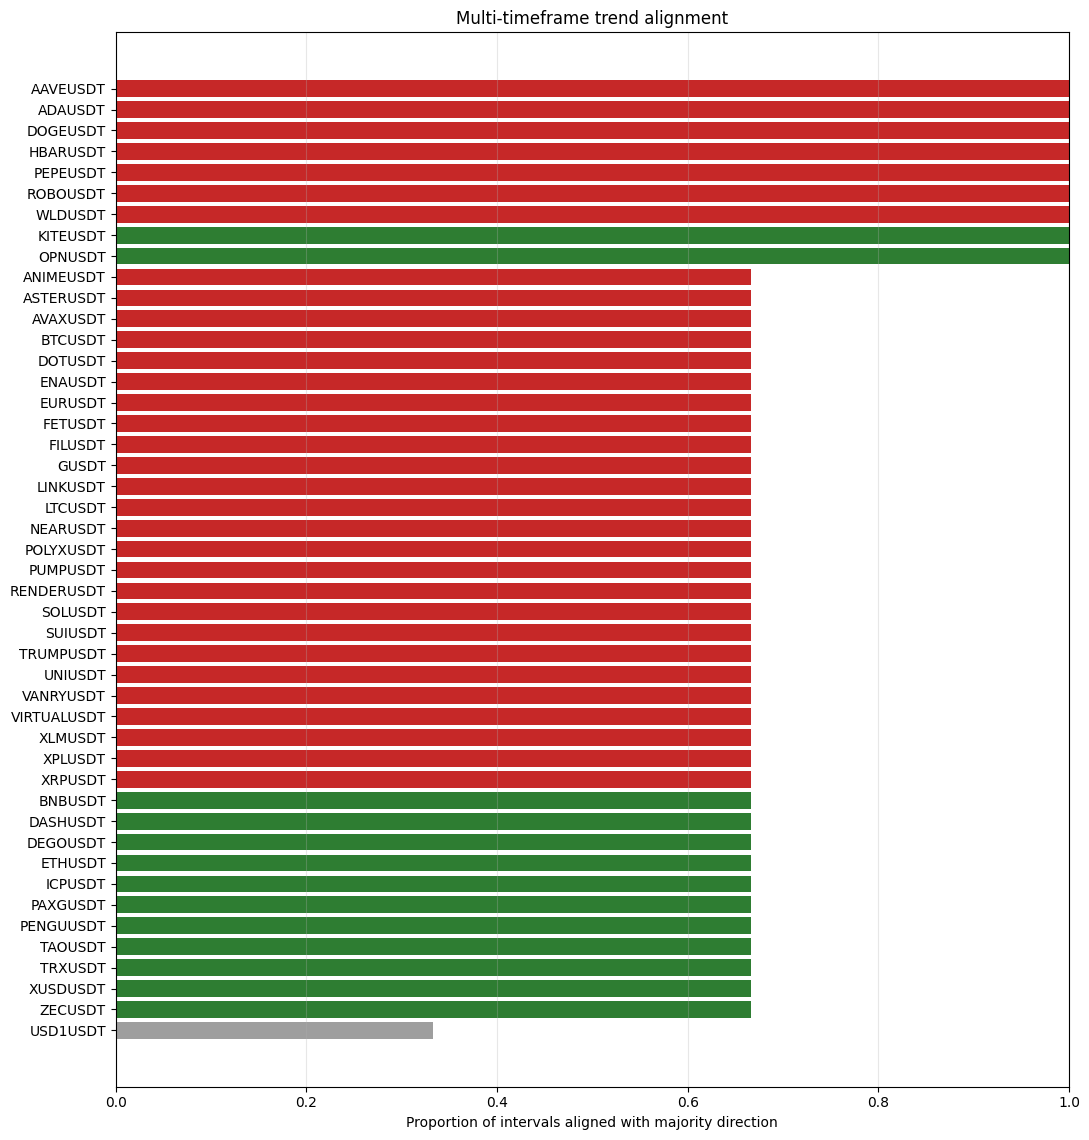

Alignment verification:
- Symbols with full multi-TF data: 46
- Fully aligned (all intervals same trend): 9 (19.6%)
- Partially aligned (majority same): 36 (78.3%)
- Conflicted (no majority): 1 (2.2%)
- Top 5 fully aligned down symbols: ['AAVEUSDT', 'ADAUSDT', 'DOGEUSDT', 'HBARUSDT', 'PEPEUSDT']
- Top 5 fully aligned up symbols: ['KITEUSDT', 'OPNUSDT']


In [ ]:
align_df = results_df[results_df['error'].isna()].copy()

records = []
for symbol, grp in align_df.groupby('symbol'):
    if set(INTERVALS) - set(grp['interval'].tolist()):
        continue

    trends = grp.set_index('interval').reindex(INTERVALS)['trend'].tolist()
    non_range = [t for t in trends if t in ['up', 'down']]
    if len(non_range) == 0:
        continue

    up_count = non_range.count('up')
    down_count = non_range.count('down')
    if up_count > down_count:
        majority = 'up'
        agree = up_count
    elif down_count > up_count:
        majority = 'down'
        agree = down_count
    else:
        majority = 'conflict'
        agree = up_count

    proportion = agree / len(INTERVALS)
    records.append({'symbol': symbol, 'majority': majority, 'agree_prop': proportion, 'up_count': up_count, 'down_count': down_count})

align_view = pd.DataFrame(records)

if len(align_view) > 0:
    align_view = align_view.sort_values(['agree_prop', 'majority', 'symbol'], ascending=[False, True, True]).reset_index(drop=True)
    color_map = {'up': '#2e7d32', 'down': '#c62828', 'conflict': '#9e9e9e'}
    colors = align_view['majority'].map(color_map).tolist()

    fig, ax = plt.subplots(figsize=(11, max(5, len(align_view) * 0.25)))
    ax.barh(align_view['symbol'], align_view['agree_prop'], color=colors)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Proportion of intervals aligned with majority direction')
    ax.set_title('Multi-timeframe trend alignment')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    full_multi = len(align_view)
    fully_aligned = int((align_view['agree_prop'] == 1.0).sum())
    partially_aligned = int(((align_view['agree_prop'] > 0.5) & (align_view['agree_prop'] < 1.0)).sum())
    conflicted = int((align_view['majority'] == 'conflict').sum())

    down_symbols = align_view[(align_view['agree_prop'] == 1.0) & (align_view['majority'] == 'down')]['symbol'].head(5).tolist()
    up_symbols = align_view[(align_view['agree_prop'] == 1.0) & (align_view['majority'] == 'up')]['symbol'].head(5).tolist()

    print('Alignment verification:')
    print(f"- Symbols with full multi-TF data: {full_multi}")
    print(f"- Fully aligned (all intervals same trend): {fully_aligned} ({(100*fully_aligned/full_multi if full_multi else 0):.1f}%)")
    print(f"- Partially aligned (majority same): {partially_aligned} ({(100*partially_aligned/full_multi if full_multi else 0):.1f}%)")
    print(f"- Conflicted (no majority): {conflicted} ({(100*conflicted/full_multi if full_multi else 0):.1f}%)")
    print(f"- Top 5 fully aligned down symbols: {down_symbols}")
    print(f"- Top 5 fully aligned up symbols: {up_symbols}")
else:
    print('Alignment verification:')
    print('- Symbols with full multi-TF data: 0')
    print('- No symbols met full-data + non-range criteria.')

In [ ]:
from pathlib import Path

scanner_root = Path('data') / 'scanner'
current_dir = None
if scanner_root.exists():
    dirs = [d for d in scanner_root.iterdir() if d.is_dir()]
    if dirs:
        current_dir = max(dirs, key=lambda p: p.name)

if current_dir is None:
    print('No previous scan found — this is the first run.')
else:
    prev_candidates = sorted(
        [d for d in scanner_root.iterdir() if d.is_dir() and d.name < current_dir.name],
        key=lambda p: p.name
    )

    if not prev_candidates:
        print('No previous scan found — this is the first run.')
    else:
        prev_dir = prev_candidates[-1]
        prev_path = prev_dir / 'results.parquet'

        if not prev_path.exists():
            print('No previous scan found — this is the first run.')
        else:
            prev_df = pd.read_parquet(prev_path)

            cur_ok = results_df[results_df['error'].isna()].copy()
            prev_ok = prev_df[prev_df['error'].isna()].copy() if 'error' in prev_df.columns else prev_df.copy()

            cur_wide = cur_ok.pivot_table(index='symbol', columns='interval', values=['trend', 'current_phase'], aggfunc='first')
            prev_wide = prev_ok.pivot_table(index='symbol', columns='interval', values=['trend', 'current_phase'], aggfunc='first')

            common_symbols = sorted(set(cur_wide.index).intersection(set(prev_wide.index)))
            trend_changed_symbols = set()
            phase_changed_symbols = set()
            retr_to_imp = set()
            imp_to_retr = set()

            for sym in common_symbols:
                for interval in INTERVALS:
                    cur_tr = cur_wide.get(('trend', interval), pd.Series(index=cur_wide.index)).get(sym, np.nan)
                    prv_tr = prev_wide.get(('trend', interval), pd.Series(index=prev_wide.index)).get(sym, np.nan)
                    cur_ph = cur_wide.get(('current_phase', interval), pd.Series(index=cur_wide.index)).get(sym, np.nan)
                    prv_ph = prev_wide.get(('current_phase', interval), pd.Series(index=prev_wide.index)).get(sym, np.nan)

                    if pd.notna(cur_tr) and pd.notna(prv_tr) and cur_tr != prv_tr:
                        trend_changed_symbols.add(sym)
                    if pd.notna(cur_ph) and pd.notna(prv_ph) and cur_ph != prv_ph:
                        phase_changed_symbols.add(sym)
                    if prv_ph == 'retracement' and cur_ph == 'impulse':
                        retr_to_imp.add(sym)
                    if prv_ph == 'impulse' and cur_ph == 'retracement':
                        imp_to_retr.add(sym)

            print('Scan comparison (current vs previous):')
            print(f"- Previous scan: {prev_dir.name}")
            print(f"- Trend direction changes: {len(trend_changed_symbols)} symbols")
            print(f"- Phase changes: {len(phase_changed_symbols)} symbols")
            print(f"- New impulse starts (retracement → impulse): {sorted(retr_to_imp)}")
            print(f"- New retracement starts (impulse → retracement): {sorted(imp_to_retr)}")

Scan comparison (current vs previous):
- Previous scan: 20260317_175311
- Trend direction changes: 0 symbols
- Phase changes: 0 symbols
- New impulse starts (retracement → impulse): []
- New retracement starts (impulse → retracement): []
